<a href="https://colab.research.google.com/github/adritoo23-prog/BIT2/blob/main/Trabajo_final_Adriana_Toro_DS_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset de Kaggle en donde se quiere evaluar el nivel de satisfaccion y lograr plantear estrategias de marketing sobre el resultado de predicción satisfaccion de los clientes

In [104]:
#importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

In [105]:
from google.colab import files
uploaded =files.upload()

Saving ecommerce_sales_analytics_5000.csv to ecommerce_sales_analytics_5000 (5).csv


In [106]:
df= pd.read_csv('ecommerce_sales_analytics_5000.csv')
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [107]:
df.shape

(5000, 12)

In [108]:
#Estadisticas del data set
df.describe()

,order_id,customer_id,quantity,unit_price,discount,delivery_days,customer_rating,revenue
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,1505.701200,4.044800,308.418774,0.179984,6.118800,2.973980,1021.955148
std,1443.520003,290.836902,2.020398,169.259369,0.101404,3.153264,1.157722,825.584219
min,10001.000000,1000.000000,1.000000,15.150000,0.000000,1.000000,1.000000,11.210000
25%,11250.750000,1253.000000,2.000000,161.895000,0.090000,3.000000,2.000000,354.527500
50%,12500.500000,1510.000000,4.000000,309.890000,0.180000,6.000000,3.000000,796.650000
75%,13750.250000,1761.000000,6.000000,455.557500,0.270000,9.000000,4.000000,1515.690000
max,15000.000000,1999.000000,7.000000,599.960000,0.350000,11.000000,5.000000,4119.330000


In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   object 
 4   region            5000 non-null   object 
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   object 
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB


In [110]:
#valores nulos
df.isnull().sum()

,0
order_id,0
order_date,0
customer_id,0
product_category,0
region,0
quantity,0
unit_price,0
discount,0
payment_method,0
delivery_days,0


In [111]:
#Creacion de variables adicionales.
# crear groos values
df["gross_value"] = df["quantity"] * df["unit_price"]
#Crear descuento
df["discount_amount"] = (
    df["gross_value"] * df["discount"]
)
#Trasformar fecha
df["order_date"] = pd.to_datetime(df["order_date"])
#Dia de la semana
df["day_of_week"] = df["order_date"].dt.dayofweek
#Mes de la compra
df["month"] = df["order_date"].dt.month
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,gross_value,discount_amount,day_of_week,month
0,10001,2022-01-01,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20,2615.55,732.3540,5,1
1,10002,2022-01-02,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10,334.18,30.0762,6,1
2,10003,2022-01-03,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35,933.84,289.4904,0,1
3,10004,2022-01-04,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90,2622.35,52.4470,1,1
4,10005,2022-01-05,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56,699.35,230.7855,2,1


In [112]:
#Eliminar duplicados
df = df.drop_duplicates()
#Eliminar order_id, customer_id, revenue
df = df.drop(["order_id", "customer_id", "revenue"], axis=1)

In [113]:
#Se Analiza la distribución de la variable objetivo.
print(df["customer_rating"].value_counts())

customer_rating
2.2    149
1.7    143
3.2    139
3.1    137
3.5    137
2.3    137
1.4    134
4.1    133
2.4    133
3.6    133
2.0    129
1.5    129
3.0    128
2.6    127
1.8    127
4.4    126
4.8    126
3.9    125
1.3    125
4.6    124
4.3    122
1.6    122
2.9    121
1.1    121
3.8    121
2.5    119
1.2    119
2.7    119
4.7    118
4.9    118
3.4    116
2.1    116
4.2    116
1.9    115
2.8    112
3.7    111
4.5    108
3.3    107
4.0    105
1.0     80
5.0     73
Name: count, dtype: int64


In [114]:
from sklearn.linear_model import LogisticRegression

In [115]:
df["satisfaction"] = df["customer_rating"].apply(
    lambda x: 1 if x >= 4 else 0
)

In [116]:
df["satisfaction_label"] = df["satisfaction"].map({
    0: "No satisfecho",
    1: "Satisfecho"
    })


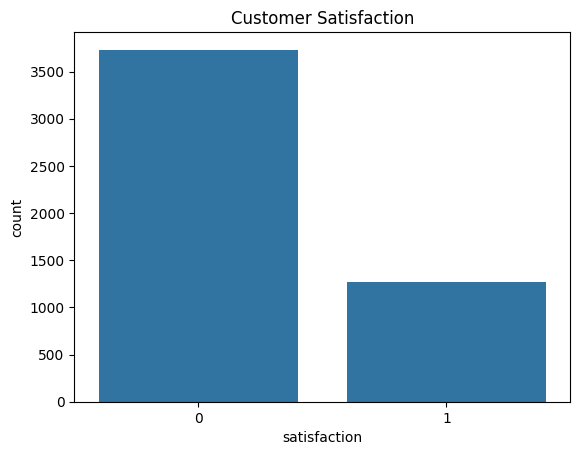

In [117]:
# visualización de las diferentes categorias que hay
sns.countplot(x='satisfaction', data=df)
plt.title('Customer Satisfaction')
plt.show()

In [118]:
print(df["satisfaction_label"].value_counts())

satisfaction_label
No satisfecho    3731
Satisfecho       1269
Name: count, dtype: int64


In [119]:
#Columna satisfaccion verdadero falso
df = pd.get_dummies(df, drop_first=True)
df.head()

,order_date,quantity,unit_price,discount,delivery_days,customer_rating,gross_value,discount_amount,day_of_week,month,satisfaction,product_category_Clothing,product_category_Electronics,product_category_Home,region_North,region_South,region_West,payment_method_Card,payment_method_Wallet,satisfaction_label_Satisfecho
0,2022-01-01,7,373.65,0.28,10,4.7,2615.55,732.3540,5,1,1,False,False,False,False,True,False,False,True,True
1,2022-01-02,7,47.74,0.09,6,3.9,334.18,30.0762,6,1,0,True,False,False,False,True,False,True,False,False
2,2022-01-03,3,311.28,0.31,6,2.5,933.84,289.4904,0,1,0,False,False,False,False,False,False,False,False,False
3,2022-01-04,5,524.47,0.02,6,1.6,2622.35,52.4470,1,1,0,False,True,False,False,False,True,False,True,False
4,2022-01-05,5,139.87,0.33,4,4.9,699.35,230.7855,2,1,1,True,False,False,False,False,True,False,True,True


In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_date                     5000 non-null   datetime64[ns]
 1   quantity                       5000 non-null   int64         
 2   unit_price                     5000 non-null   float64       
 3   discount                       5000 non-null   float64       
 4   delivery_days                  5000 non-null   int64         
 5   customer_rating                5000 non-null   float64       
 6   gross_value                    5000 non-null   float64       
 7   discount_amount                5000 non-null   float64       
 8   day_of_week                    5000 non-null   int32         
 9   month                          5000 non-null   int32         
 10  satisfaction                   5000 non-null   int64         
 11  product_category_

In [122]:
# X: Conjunto de caracteristicas
X = df.drop( columns=[
        "customer_rating",
        "satisfaction",
        "satisfaction_label_Satisfecho",
        "order_date"
    ]
)
# y: Variable Objetivo
y = df["satisfaction"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)



Dimensiones de X: (5000, 16)
Dimensiones de y: (5000,)


In [130]:
#separo el entrenamiento y la prueba sin usar el 100% de la data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (4000, 16)
Prueba: (1000, 16)


In [139]:
# División en conjuntos de entrenamiento y prueba (usa stratify para respetar proporción de clases)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [140]:
display(X_train_scaled)

array([[-1.0229814 ,  0.35643618,  1.19562534, ..., -0.58966846,
         1.09886556, -0.48589499],
       [ 1.45847742,  0.43593342,  0.30136555, ..., -0.58966846,
         1.09886556, -0.48589499],
       [ 0.96218565,  0.05661973, -1.58651623, ...,  1.69586821,
        -0.91002943, -0.48589499],
       ...,
       [ 0.96218565, -0.91291505,  0.79817654, ...,  1.69586821,
        -0.91002943, -0.48589499],
       [-0.03039787, -0.88621866, -0.79161864, ..., -0.58966846,
        -0.91002943, -0.48589499],
       [ 0.46589389,  1.49615306,  0.79817654, ...,  1.69586821,
         1.09886556, -0.48589499]])

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/l


Logistic Regression - Accuracy: 0.7460 | F1 Macro: 0.4273
              precision    recall  f1-score   support

           0       0.75      1.00      0.85       746
           1       0.00      0.00      0.00       254

    accuracy                           0.75      1000
   macro avg       0.37      0.50      0.43      1000
weighted avg       0.56      0.75      0.64      1000



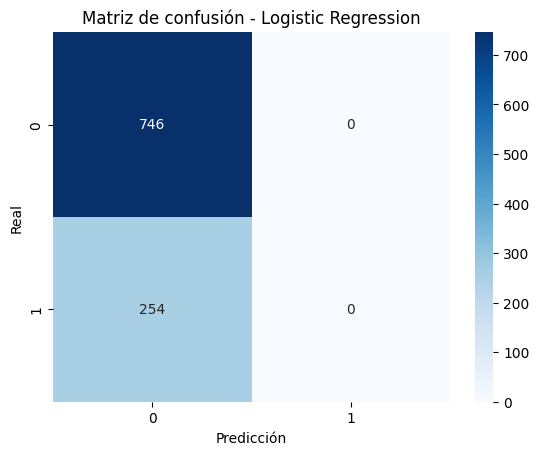


KNN - Accuracy: 0.6950 | F1 Macro: 0.4889
              precision    recall  f1-score   support

           0       0.75      0.89      0.81       746
           1       0.27      0.12      0.16       254

    accuracy                           0.69      1000
   macro avg       0.51      0.50      0.49      1000
weighted avg       0.63      0.69      0.65      1000



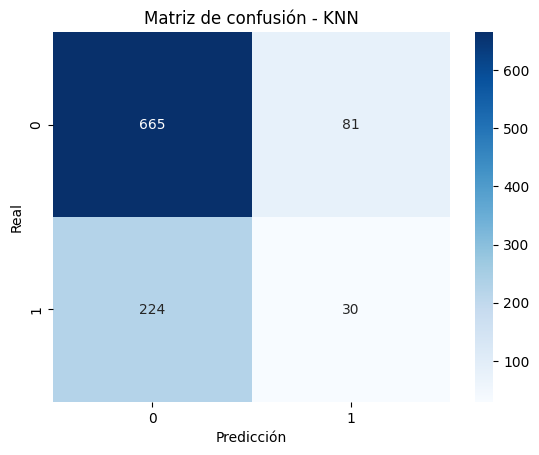


Decision Tree - Accuracy: 0.6030 | F1 Macro: 0.4947
              precision    recall  f1-score   support

           0       0.74      0.71      0.73       746
           1       0.25      0.28      0.26       254

    accuracy                           0.60      1000
   macro avg       0.50      0.50      0.49      1000
weighted avg       0.62      0.60      0.61      1000



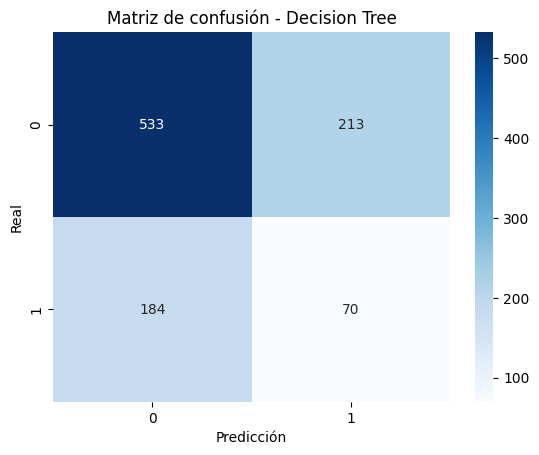


Random Forest - Accuracy: 0.7400 | F1 Macro: 0.4327
              precision    recall  f1-score   support

           0       0.75      0.99      0.85       746
           1       0.20      0.01      0.02       254

    accuracy                           0.74      1000
   macro avg       0.47      0.50      0.43      1000
weighted avg       0.61      0.74      0.64      1000



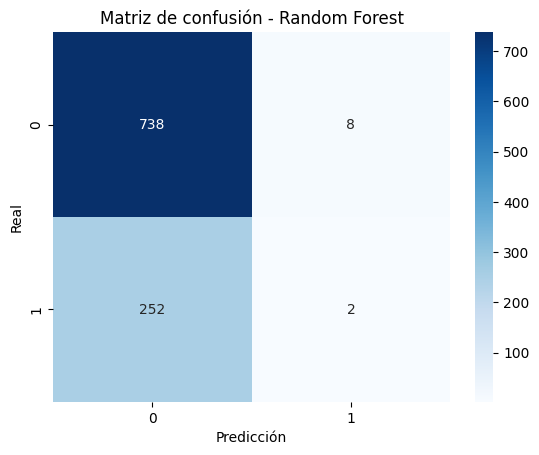


SVC (Linear) - Accuracy: 0.7460 | F1 Macro: 0.4273
              precision    recall  f1-score   support

           0       0.75      1.00      0.85       746
           1       0.00      0.00      0.00       254

    accuracy                           0.75      1000
   macro avg       0.37      0.50      0.43      1000
weighted avg       0.56      0.75      0.64      1000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


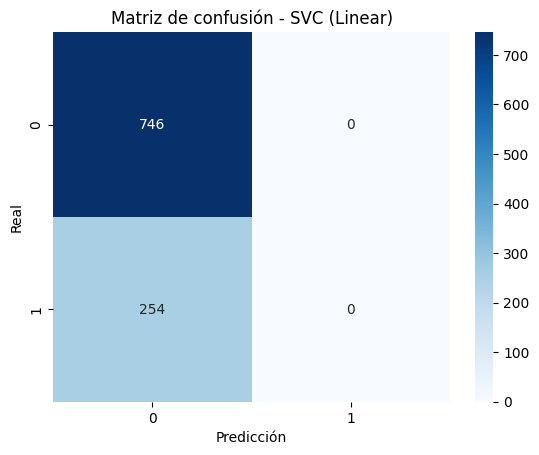


GaussianNB - Accuracy: 0.7460 | F1 Macro: 0.4273
              precision    recall  f1-score   support

           0       0.75      1.00      0.85       746
           1       0.00      0.00      0.00       254

    accuracy                           0.75      1000
   macro avg       0.37      0.50      0.43      1000
weighted avg       0.56      0.75      0.64      1000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


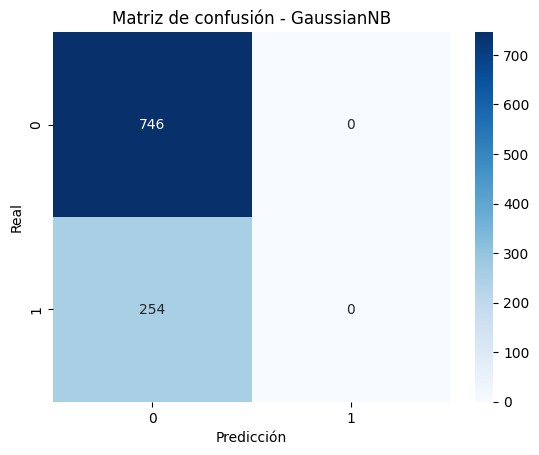

In [125]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200, multi_class='multinomial', solver='lbfgs'),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVC (Linear)": SVC(kernel='linear', probability=True, random_state=42),
    "GaussianNB": GaussianNB()
}
results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train) # ENTRENAR
    y_pred = model.predict(X_test_scaled) # PREDICCION
    # EVALUAR MODELO
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    results[name] = {
        "model": model,
        "accuracy": acc,
        "f1_macro": f1_macro,
        "y_pred": y_pred
    }
    print(f"\n{name} - Accuracy: {acc:.4f} | F1 Macro: {f1_macro:.4f}")
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de confusión - {name}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

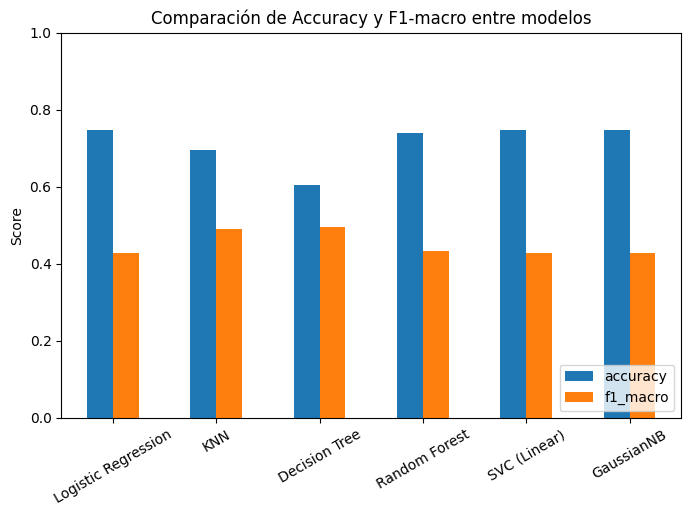

In [144]:
metricas = pd.DataFrame({
    'accuracy': {name: res['accuracy'] for name, res in results.items()},
    'f1_macro': {name: res['f1_macro'] for name, res in results.items()}
})

metricas.plot(kind='bar', figsize=(8,5))
plt.title('Comparación de Accuracy y F1-macro entre modelos')
plt.ylabel('Score')
plt.ylim(0,1)
plt.xticks(rotation=30)
plt.legend(loc='lower right')
plt.show()

¿Se cumplió el objetivo?
Si, sin embargo es esencial identificar para poder realizar un trabajo con mercadeo y mejorar la satisfaccion usando informacion mas detallada sobre los comentarios de la calificación  
¿Qué hallazgos relevantes se encontraron?
los modelos son similares precisamente porque el rango es muy cerrado al ser binario
¿Qué valor aportaría este proyecto a una organización?
permite identificar con alguna informacion como el delivery la insatisfaccion que genera al cliente ese aspecto

Segun el resultado